# Ejercicio Iris — Keras

**Copia de trabajo de `05 Keras - multilayer perceptron - iris.ipynb`.**
Preparada para ejecutar en Colab: las salidas están vacías hasta que tú ejecutes las celdas.
Se conserva primero la red original y después se añade la profunda. Ambas usan SGD 0.03,
sigmoides, MSE y 500 épocas. Se mide tiempo y accuracy de entrenamiento sin cambiar la pérdida.


In [16]:
import sys, json, platform
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
import numpy as np
ART = Path('evidencias_keras')
ART.mkdir(exist_ok=True)
en_colab = 'google.colab' in sys.modules
if not en_colab:
    try:
        import google.colab
        en_colab = True
    except ImportError:
        pass
entorno = {'fecha_utc': datetime.now(timezone.utc).isoformat(),
            'python': platform.python_version(), 'numpy': np.__version__,
            'colab_detectado': en_colab}
print(entorno)
print('Toma una captura donde se vea la interfaz de Colab y el nombre del notebook.')
(ART / 'entorno.json').write_text(json.dumps(entorno, indent=2), encoding='utf-8')


{'fecha_utc': '2026-09-13T01:10:06.667161+00:00', 'python': '3.13.15', 'numpy': '2.1.3', 'colab_detectado': True}
Toma una captura donde se vea la interfaz de Colab y el nombre del notebook.


123

## A. Ejecutar la red original 4 → 3 → 3

Ejecuta las celdas originales de abajo. Se añade semilla 42 antes de construir el modelo y
un cronómetro alrededor de `fit`. La topología y los ajustes de entrenamiento se conservan.
Toma una captura de `model.summary()` (dos Dense) y de la curva de pérdida.


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [3]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [4]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [5]:
keras.utils.set_random_seed(42)
model = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
  ]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
y = model(X)
print(y[149])

tf.Tensor([0.75035655 0.497021   0.5582423 ], shape=(3,), dtype=float32)


In [7]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
inicio_keras_original = perf_counter()
history = model.fit(X, Y, epochs=500)
segundos_keras_original = perf_counter() - inicio_keras_original


Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3006  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2990 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2973
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2957 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2941 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2926 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2910 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2895 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2879 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2864 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2849 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2834 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2820 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2805 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2791 
Epoch 16/500
5/5 ━

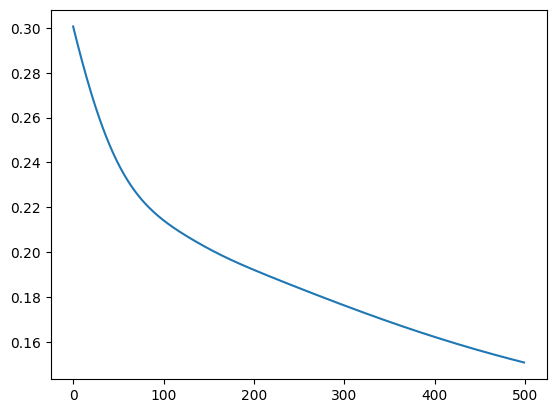

In [8]:
plt.plot(history.history['loss'])
plt.show()

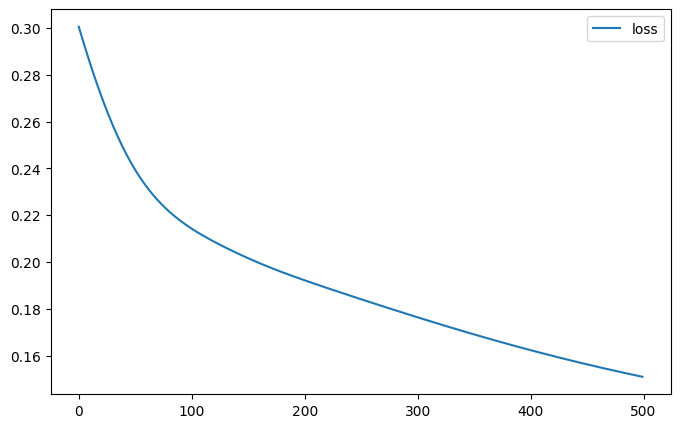

In [9]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [10]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([[0.5178732 , 0.28180325, 0.19554119]], dtype=float32)

Resultados Keras original
{
  "version": "Original",
  "topologia": "4-3-3",
  "loss_ultima_epoca": 0.15090695023536682,
  "mse_final": 0.15083876252174377,
  "accuracy_entrenamiento": 0.6666666666666666,
  "segundos": 34.849086994000004
}


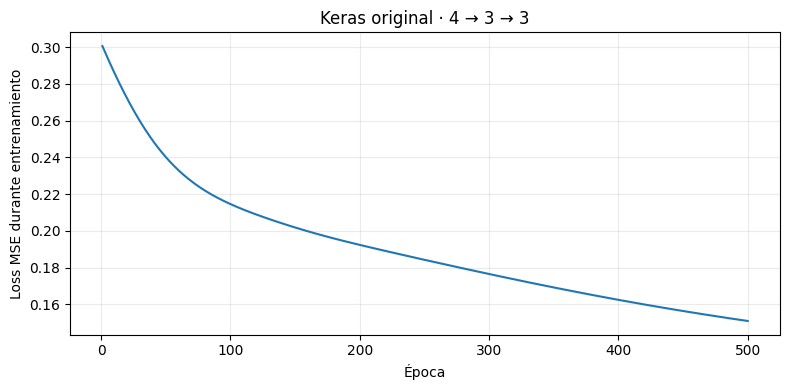

In [11]:
modelo_original = model
historia_original = np.array(history.history['loss']).copy()
pred = modelo_original.predict(X, verbose=0)
resultado_original = {
    'version': 'Original', 'topologia': '4-3-3',
    'loss_ultima_epoca': float(historia_original[-1]),
    'mse_final': float(np.mean((Y - pred) ** 2)),
    'accuracy_entrenamiento': float(np.mean(pred.argmax(axis=1) == target)),
    'segundos': segundos_keras_original,
}
print('Resultados Keras original')
print(json.dumps(resultado_original, indent=2, ensure_ascii=False))
lineas_summary = []
modelo_original.summary(print_fn=lambda texto, **kwargs: lineas_summary.append(texto))
(ART / 'keras_original_summary.txt').write_text('\n'.join(lineas_summary), encoding='utf-8')
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, 501), historia_original)
ax.set(xlabel='Época', ylabel='Loss MSE durante entrenamiento', title='Keras original · 4 → 3 → 3')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(ART / 'keras_original.png', dpi=160)
plt.show()


## B. Añadir dos capas ocultas

La arquitectura siguiente tiene cuatro Dense de tres neuronas: tres ocultas y la salida.
`keras.Input(shape=(4,))` declara las entradas y no agrega una capa Dense.
Comprueba que el summary muestra cuatro Dense y 51 parámetros de la red.
La arquitectura original tiene 27 parámetros.

El `fit` original utiliza los valores por defecto `batch_size=32` y `shuffle=True`.
Aquí se hacen explícitos para conservarlos. Cada red tiene su propio optimizador nuevo.


In [12]:
keras.utils.set_random_seed(42)
modelo_profundo = keras.Sequential([
    keras.Input(shape=(4,)),
    layers.Dense(3, activation='sigmoid', name='layer1'),
    layers.Dense(3, activation='sigmoid', name='layer2'),
    layers.Dense(3, activation='sigmoid', name='layer3'),
    layers.Dense(3, activation='sigmoid', name='layer4'),
], name='iris_profunda')
modelo_profundo.summary()
assert len([l for l in modelo_profundo.layers if isinstance(l, layers.Dense)]) == 4
assert modelo_profundo.count_params() == 51
lineas_summary = []
modelo_profundo.summary(print_fn=lambda texto, **kwargs: lineas_summary.append(texto))
(ART / 'keras_profunda_summary.txt').write_text('\n'.join(lineas_summary), encoding='utf-8')


Model: "iris_profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

966

In [13]:
modelo_profundo.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.03),
    loss=keras.losses.MeanSquaredError(),
)
inicio_profunda = perf_counter()
history_profunda = modelo_profundo.fit(X, Y, epochs=500, batch_size=32, shuffle=True)
segundos_profunda = perf_counter() - inicio_profunda
historia_profunda = np.array(history_profunda.history['loss'])
pred = modelo_profundo.predict(X, verbose=0)
resultado_profunda = {
    'version': 'Profunda', 'topologia': '4-3-3-3-3',
    'loss_ultima_epoca': float(historia_profunda[-1]),
    'mse_final': float(np.mean((Y - pred) ** 2)),
    'accuracy_entrenamiento': float(np.mean(pred.argmax(axis=1) == target)),
    'segundos': segundos_profunda,
}
print('Resultados Keras profunda')
print(json.dumps(resultado_profunda, indent=2, ensure_ascii=False))


Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3097 
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3081
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3066
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3051
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3036
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3021
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3007
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2992
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2978
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2964
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2951 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2937
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2924
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2911
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2898
Epoch 16/500
5/5 

Resultados Keras profunda
{
  "version": "Profunda",
  "topologia": "4-3-3-3-3",
  "loss_ultima_epoca": 0.22171808779239655,
  "mse_final": 0.22171393036842346,
  "accuracy_entrenamiento": 0.5,
  "segundos": 36.13081558800002
}


## C. Comparación y predicción

La loss de `fit` promedia los lotes mientras los pesos están cambiando. `mse_final` se calcula
después de entrenar con los pesos finales, y puede diferir un poco de la última loss.
Para comparar con NumPy usa `mse_final`, que tiene la misma definición en ambos notebooks.

Las sigmoides no obligan a que las tres salidas sumen uno. Para escoger la clase usamos argmax.
La accuracy es de entrenamiento, no de datos nuevos.


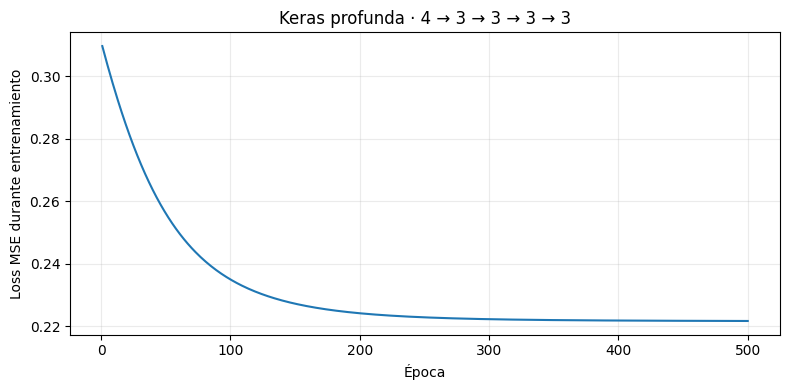

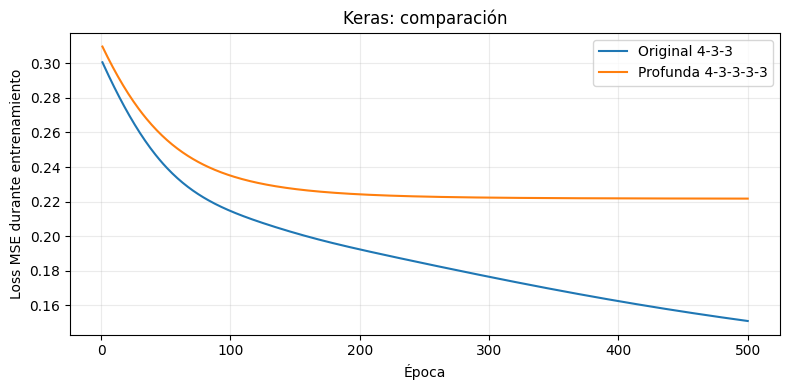

,version,topologia,loss_ultima_epoca,mse_final,accuracy_entrenamiento,segundos
0,Original,4-3-3,0.150907,0.150839,0.666667,34.849087
1,Profunda,4-3-3-3-3,0.221718,0.221714,0.500000,36.130816


Original | salidas: [0.5178732  0.28180325 0.19554119] | clase elegida: setosa
Profunda | salidas: [0.34232172 0.33883744 0.33637056] | clase elegida: setosa


149

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, 501), historia_profunda)
ax.set(xlabel='Época', ylabel='Loss MSE durante entrenamiento', title='Keras profunda · 4 → 3 → 3 → 3 → 3')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(ART / 'keras_profunda.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, 501), historia_original, label='Original 4-3-3')
ax.plot(np.arange(1, 501), historia_profunda, label='Profunda 4-3-3-3-3')
ax.set(xlabel='Época', ylabel='Loss MSE durante entrenamiento', title='Keras: comparación')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(ART / 'keras_comparacion.png', dpi=160)
plt.show()

tabla_keras = pd.DataFrame([resultado_original, resultado_profunda])
display(tabla_keras)
tabla_keras.to_csv(ART / 'resultados_keras.csv', index=False)
np.savez(ART / 'curvas_keras.npz', original=historia_original, profunda=historia_profunda)
for nombre, modelo in [('Original', modelo_original), ('Profunda', modelo_profundo)]:
    salida = modelo.predict(np.array([[3, 3, 1, 1]], dtype=float), verbose=0)[0]
    print(nombre, '| salidas:', salida, '| clase elegida:', iris.target_names[salida.argmax()])
entorno['tensorflow'] = tf.__version__
(ART / 'entorno.json').write_text(json.dumps(entorno, indent=2), encoding='utf-8')


## D. Descargar evidencias

La siguiente celda descarga las figuras y números. Guarda también capturas de ambos summary
en la interfaz de Colab. Después descarga el notebook ejecutado desde Archivo → Descargar → .ipynb.
Conserva los notebooks de NumPy y Keras, sus evidencias y el reporte completado con tus números.

Documentación: [Sequential](https://keras.io/guides/sequential_model/),
[fit y sus valores por defecto](https://keras.io/api/models/model_training_apis/),
[MeanSquaredError](https://keras.io/api/losses/regression_losses/).


In [15]:
import shutil
archivo = shutil.make_archive('evidencias_keras', 'zip', ART)
print('Evidencias generadas:', archivo)
try:
    from google.colab import files
    files.download(archivo)
except ImportError:
    print('Abre el archivo ZIP desde el entorno donde ejecutaste el notebook.')


Evidencias generadas: /content/evidencias_keras.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>